In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150


df = pd.read_pickle('../data/processed/superstore_eda_ready.pkl')

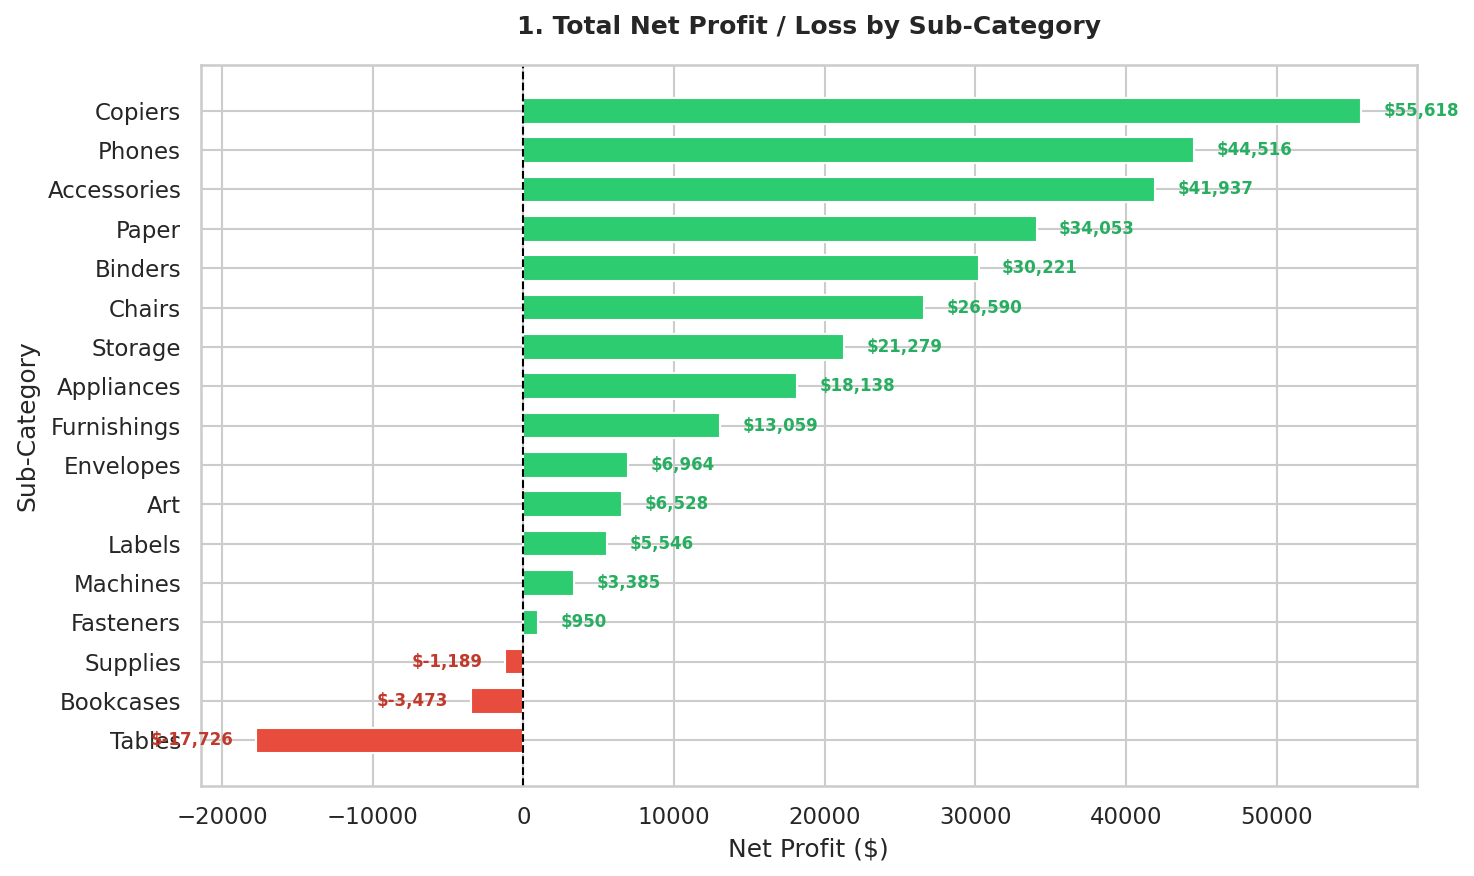

In [6]:
# Chart 1: Net Profit by Sub-Category (Identifying Loss-Makers)

subcat_profit = df.groupby('Sub-Category', observed=True)['Profit'].sum().sort_values()


colors = ['#e74c3c' if val < 0 else '#2ecc71' for val in subcat_profit.values]

plt.figure(figsize=(10, 6))
bars = plt.barh(subcat_profit.index, subcat_profit.values, color=colors, height=0.65)


for bar in bars:
    w = bar.get_width()
    offset = -1500 if w < 0 else 1500
    ha = 'right' if w < 0 else 'left'
    plt.text(w + offset, bar.get_y() + bar.get_height()/2, f"${w:,.0f}", 
             va='center', ha=ha, fontsize=8, fontweight='bold',
             color='#c0392b' if w < 0 else '#27ae60')

plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title('1. Total Net Profit / Loss by Sub-Category', fontweight='bold', pad=15)
plt.xlabel('Net Profit ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

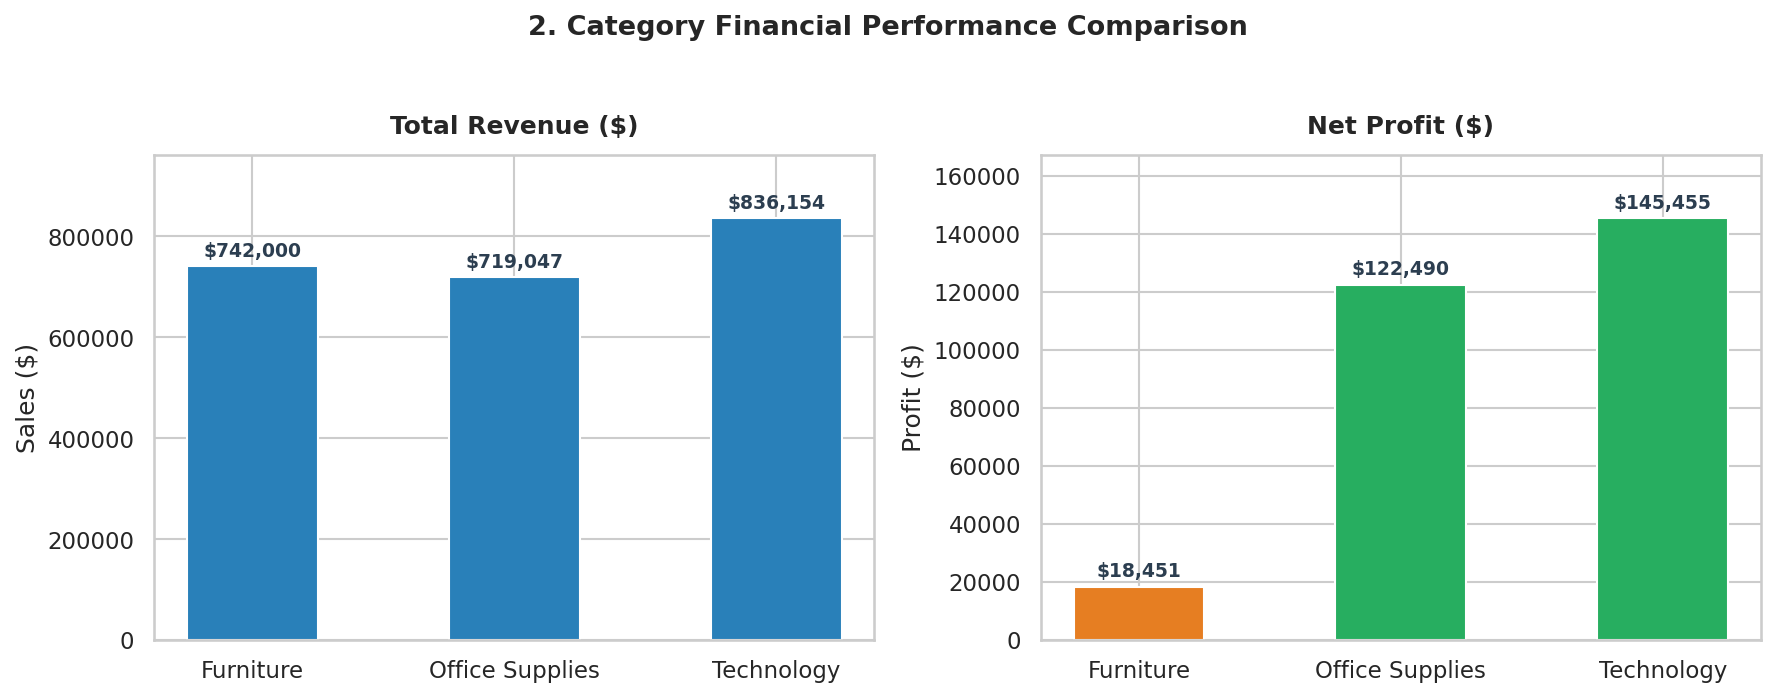

In [9]:
# ==============================================================================
# Chart 2 (Side-by-Side): Total Sales vs. Net Profit across Categories
# ==============================================================================
cat_data = df.groupby('Category', observed=True)[['Sales', 'Profit']].sum().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Sales Plot (Left)
bars1 = ax1.bar(cat_data['Category'], cat_data['Sales'], color='#2980b9', width=0.5)
ax1.set_title('Total Revenue ($)', fontweight='bold', pad=10)
ax1.set_ylabel('Sales ($)')
ax1.set_ylim(0, cat_data['Sales'].max() * 1.15)
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 10000, f"${h:,.0f}", 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2c3e50')

# 2. Profit Plot (Right) - Furniture highlighted in orange/red
profit_colors = ['#e67e22' if cat == 'Furniture' else '#27ae60' for cat in cat_data['Category']]
bars2 = ax2.bar(cat_data['Category'], cat_data['Profit'], color=profit_colors, width=0.5)
ax2.set_title('Net Profit ($)', fontweight='bold', pad=10)
ax2.set_ylabel('Profit ($)')
ax2.set_ylim(0, cat_data['Profit'].max() * 1.15)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 2000, f"${h:,.0f}", 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2c3e50')

plt.suptitle('2. Category Financial Performance Comparison', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

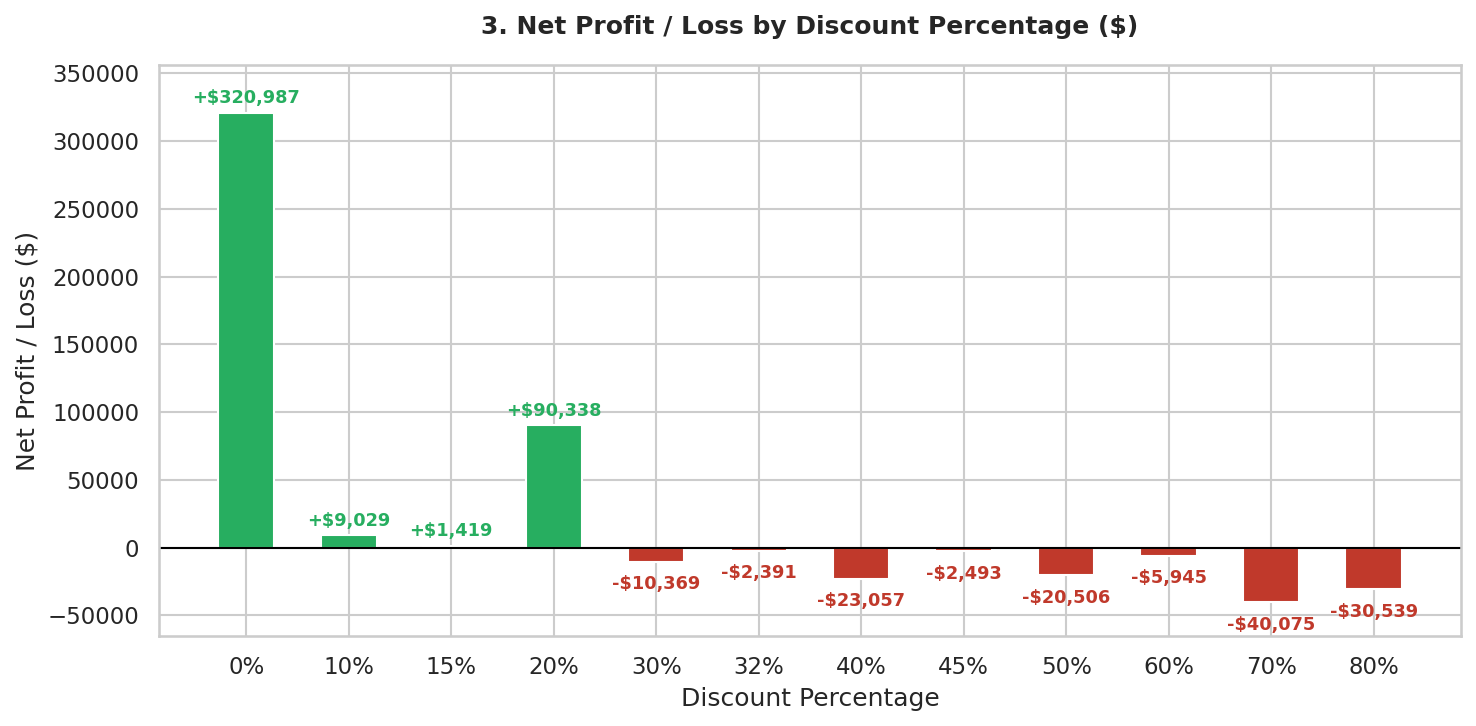

In [12]:
# ==============================================================================
# Chart 3 (Intuitive): Total Profit or Loss by Discount Level ($)
# ==============================================================================
discount_profit = df.groupby('Discount', observed=True)['Profit'].sum().reset_index()

# تلوين الخصومات اللي جابت مكسب بالأخضر، واللي جابت خسارة بالأحمر
bar_colors = ['#27ae60' if p >= 0 else '#c0392b' for p in discount_profit['Profit']]

plt.figure(figsize=(10, 5))
bars = plt.bar(
    discount_profit['Discount'].apply(lambda x: f"{int(x*100)}%"), 
    discount_profit['Profit'], 
    color=bar_colors, 
    width=0.55
)

# خط الصفر للفصل بين الربح والخسارة
plt.axhline(0, color='black', linewidth=1)

# كتابة الأرقام بالدولار فوق وتحت الأعمدة
for bar in bars:
    h = bar.get_height()
    va = 'bottom' if h >= 0 else 'top'
    offset = 4000 if h >= 0 else -10000
    label = f"+${h:,.0f}" if h >= 0 else f"-${abs(h):,.0f}"
    plt.text(bar.get_x() + bar.get_width()/2, h + offset, label,
             ha='center', va=va, fontsize=8.5, fontweight='bold',
             color='#27ae60' if h >= 0 else '#c0392b')

plt.title('3. Net Profit / Loss by Discount Percentage ($)', fontweight='bold', pad=15)
plt.xlabel('Discount Percentage')
plt.ylabel('Net Profit / Loss ($)')
plt.ylim(discount_profit['Profit'].min() - 25000, discount_profit['Profit'].max() + 35000)
plt.tight_layout()
plt.show()

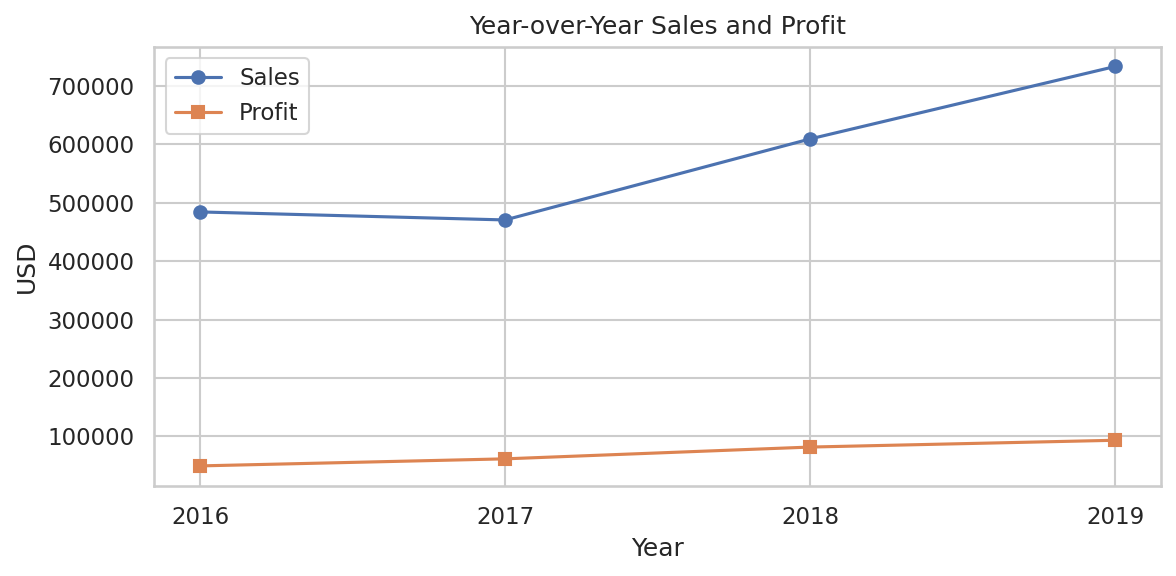

In [19]:
yearly = df.groupby('Order_Year')[['Sales', 'Profit']].sum()

plt.figure(figsize=(8, 4))
plt.plot(yearly.index, yearly['Sales'], marker='o', label='Sales')
plt.plot(yearly.index, yearly['Profit'], marker='s', label='Profit')

plt.title('Year-over-Year Sales and Profit')
plt.xlabel('Year')
plt.ylabel('USD')
plt.xticks(yearly.index)
plt.legend()
plt.tight_layout()
plt.show()


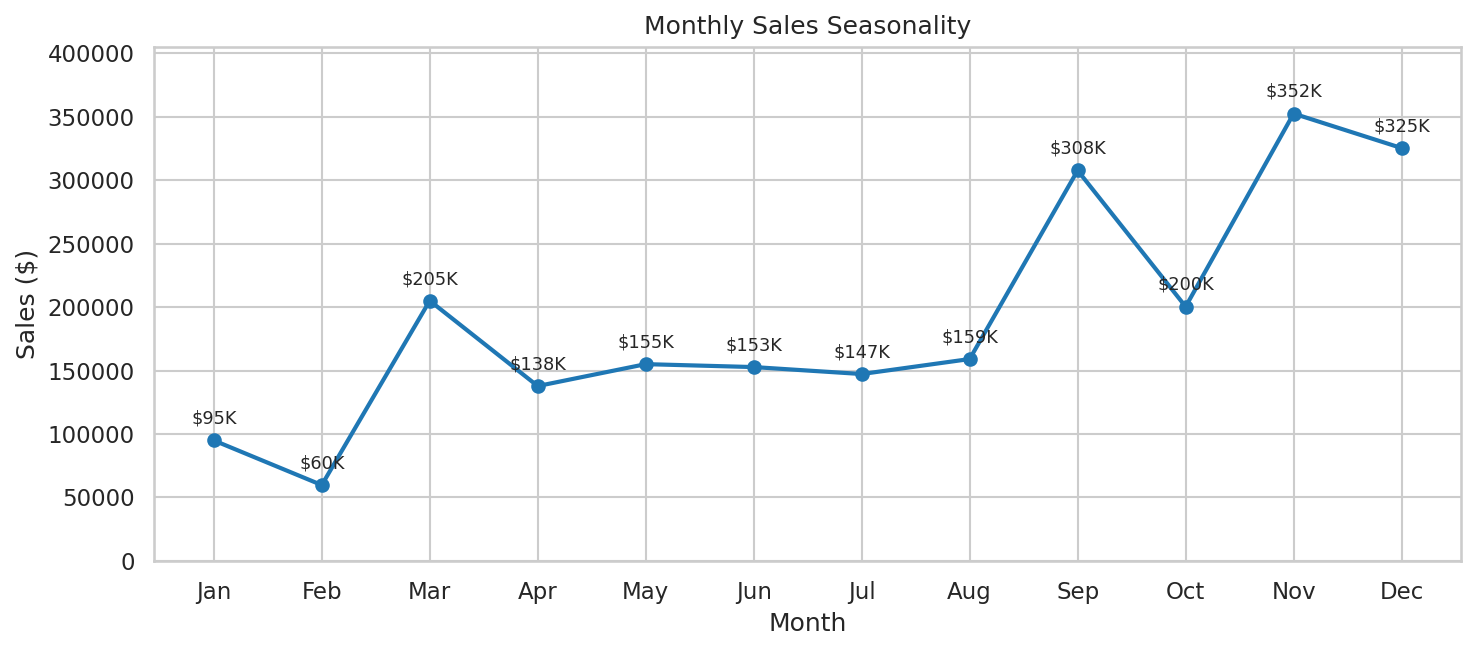

In [24]:
# تجميع المبيعات حسب رقم الشهر عشان الترتيب يكون مظبوط
monthly = df.groupby('Order_Month')['Sales'].sum()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 4.5))
plt.plot(monthly.index, monthly.values, marker='o', color='#1f77b4', linewidth=2)

plt.title('Monthly Sales Seasonality')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(ticks=range(1, 13), labels=months)

# إضافة الأرقام فوق النقط
for x, y in zip(monthly.index, monthly.values):
    plt.annotate(f"${y/1e3:.0f}K", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8.5)

plt.ylim(0, monthly.max() * 1.15)
plt.tight_layout()
plt.show()

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_29588\1957050218.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_rate = (df.groupby('Ship Mode')['Is_Delayed'].mean() * 100).sort_values(ascending=False)


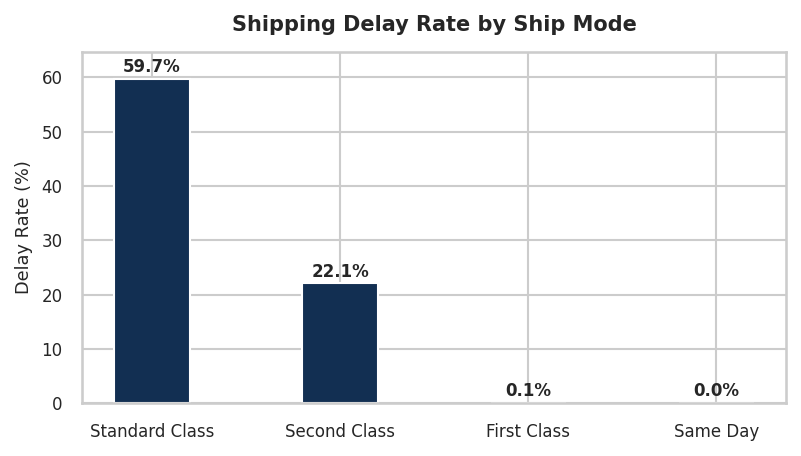

In [30]:
delay_rate = (df.groupby('Ship Mode')['Is_Delayed'].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(5.5, 3.2))
bars = plt.bar(delay_rate.index, delay_rate.values, color="#122f52", width=0.4)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%", 
             ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.title('Shipping Delay Rate by Ship Mode', fontsize=10, fontweight='bold', pad=10)
plt.ylabel('Delay Rate (%)', fontsize=8.5)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.ylim(0, delay_rate.max() + 5)
plt.tight_layout()
plt.show()

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_29588\3530161047.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment = df.groupby('Segment')[['Sales', 'Profit']].sum()


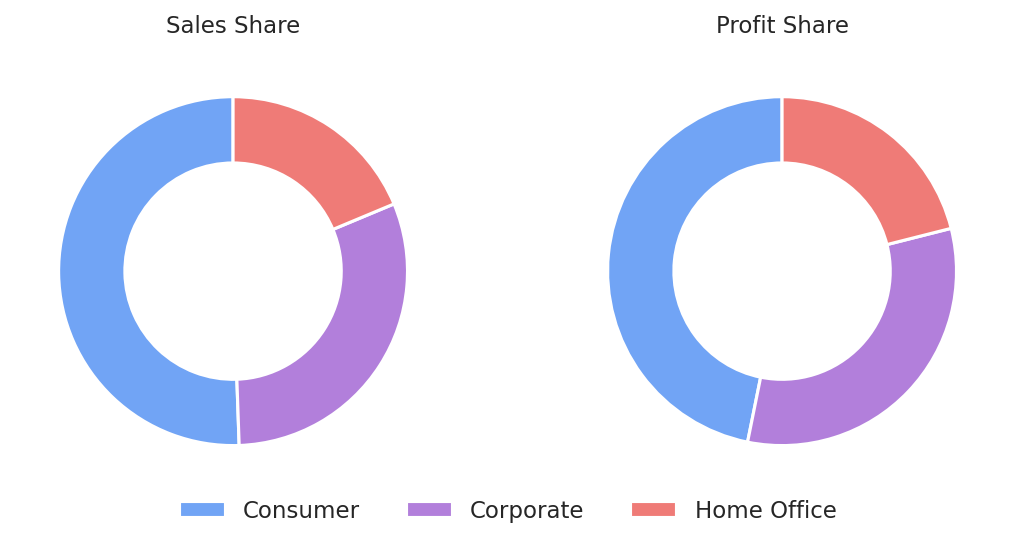

In [38]:
segment = df.groupby('Segment')[['Sales', 'Profit']].sum()

# باليت ألوان هادية ومتناسقة
colors = ["#71A4F5", "#B27FDB", "#EF7B77"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.5))

# 1. Sales Donut
wedges1, _ = ax1.pie(segment['Sales'], colors=colors, startangle=90, 
                     wedgeprops=dict(width=0.38, edgecolor='white', linewidth=1.5))
ax1.set_title('Sales Share', fontsize=11, pad=10)

# 2. Profit Donut
wedges2, _ = ax2.pie(segment['Profit'], colors=colors, startangle=90, 
                     wedgeprops=dict(width=0.38, edgecolor='white', linewidth=1.5))
ax2.set_title('Profit Share', fontsize=11, pad=10)

# دليل ألوان مشترك وموحد تحت الرسمتين
fig.legend(wedges1, segment.index, loc="lower center", 
           bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_29588\1287686023.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_vip = df.groupby('Customer Name')['Sales'].sum().nlargest(10).sort_values()


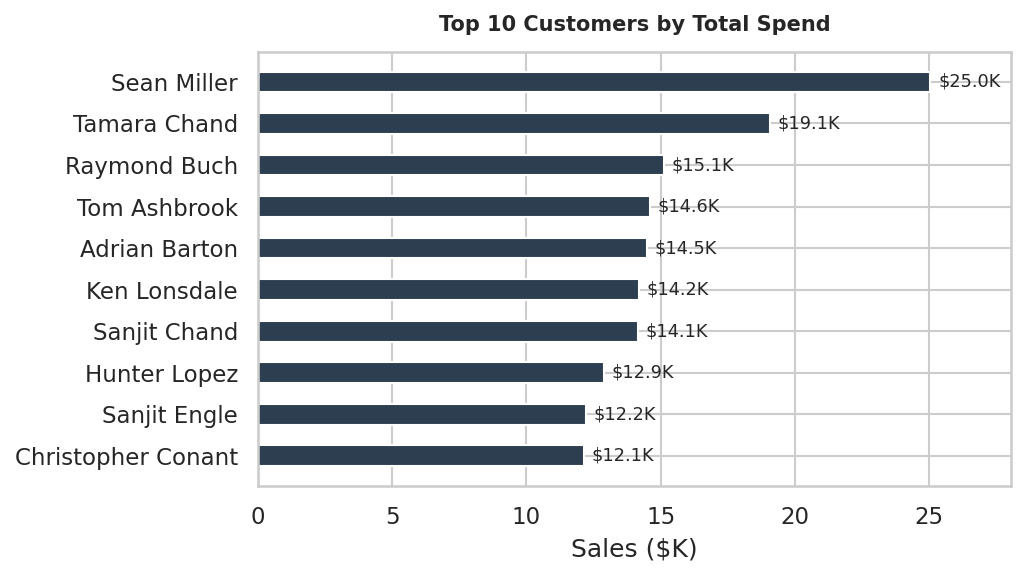

In [41]:
top_vip = df.groupby('Customer Name')['Sales'].sum().nlargest(10).sort_values()

plt.figure(figsize=(7, 4))
bars = plt.barh(top_vip.index, top_vip.values / 1e3, color='#2c3e50', height=0.5)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.3, bar.get_y() + bar.get_height()/2, f"${w:.1f}K", 
             va='center', fontsize=8.5)

plt.title('Top 10 Customers by Total Spend', fontsize=10, fontweight='bold', pad=10)
plt.xlabel('Sales ($K)')
plt.xlim(0, (top_vip.max() / 1e3) + 3)
plt.tight_layout()
plt.show()